# Beginner walkthrough: prompt template evaluation with promptstats

This notebook shows how to benchmark multiple prompt templates on a sentiment task, analyze statistical differences with `promptstats`, and visualize results.

## What you'll do

1. Define labeled input examples and prompt templates.
2. Run repeated LLM calls for each `(template, input)` pair.
3. Build a `BenchmarkResult` and run `promptstats.analyze`.
4. Plot template advantage and variability.

In [21]:
import math
import os
import re
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

# This is a bit hacky but allows us to import promptstats from the project root even when running tests 
# from the examples/ directory.
project_root = Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import promptstats as pstats

## Step 1: Benchmark setup

Define a small sentiment dataset and multiple prompt template styles.

In [22]:
INPUTS = [
    # (review text, ground_truth_label)

    # --- Easy / unambiguous ---
    ("This product exceeded all my expectations. Absolutely love it!",         "POSITIVE"),
    ("Complete waste of money. Broke after two days.",                         "NEGATIVE"),
    ("It works fine. Does what it says on the box.",                           "NEUTRAL"),
    ("Best purchase I've made all year. Five stars!",                          "POSITIVE"),
    ("Terrible customer service. Will never buy again.",                       "NEGATIVE"),
    ("Average quality. Neither impressed nor disappointed.",                   "NEUTRAL"),
    ("Shipping was fast and the item looks great. Very happy.",                "POSITIVE"),
    ("The color is different from the photos. Feels cheap.",                   "NEGATIVE"),
    ("Incredibly sturdy build. Worth every penny.",                            "POSITIVE"),
    ("Decent enough for the price. Not amazing.",                              "NEUTRAL"),
    ("Surpassed my expectations in every way!",                                "POSITIVE"),
    ("Completely useless. Don't waste your time.",                             "NEGATIVE"),
    ("It's okay. I've seen better but I've also seen worse.",                  "NEUTRAL"),

    # --- Challenging: sarcasm (surface words are positive, meaning is negative) ---
    ("Oh wonderful, it broke on the very first day.",                              "NEGATIVE"),
    ("Sure, I love spending 45 minutes on hold.",                                  "NEGATIVE"),
    ("Impressive how something so simple can go so spectacularly wrong.",          "NEGATIVE"),

    # --- Challenging: double negatives / hedged language ---
    ("Not entirely without merit, though not exactly impressive either.",          "NEUTRAL"),
    ("I can't say I wasn't disappointed — yet somehow I wasn't fully let down.",   "NEUTRAL"),
    ("It's not like it doesn't work. It works. Just not well.",                    "NEGATIVE"),

    # --- Challenging: mixed / split sentiment ---
    ("The hardware is excellent but the software makes the whole thing unusable.",  "NEGATIVE"),
    ("Great concept, poor execution. So close, yet so far.",                       "NEGATIVE"),
    ("Fast delivery and nice packaging; the product itself is deeply mediocre.",   "NEUTRAL"),

    # --- Challenging: understatement / implied sentiment ---
    ("Let's just say I won't be ordering a second one.",                           "NEGATIVE"),
    ("Pleasantly surprised — I expected nothing and got slightly more than that.", "POSITIVE"),
    ("For a product that does practically nothing, it does it quite consistently.", "NEUTRAL"),
]

TEMPLATES = {
    "Minimal": (
        "Classify the sentiment of the following text.\n"
        "Reply with exactly one word: POSITIVE, NEGATIVE, or NEUTRAL.\n\n"
        "Text: {text}\n\n"
        "Sentiment:"
    ),
    "Instructive": (
        "You are a precise sentiment classifier.\n"
        "Classify as POSITIVE, NEGATIVE, or NEUTRAL.\n"
        "Return only the label.\n\n"
        "Text: {text}\n\nSentiment:"
    ),
    "Few-shot": (
        "Classify sentiment as POSITIVE, NEGATIVE, or NEUTRAL.\n\n"
        "Example: Text: It stopped working after a week. Sentiment: NEGATIVE\n"
        "Example: Text: Arrived in good condition. Sentiment: NEUTRAL\n"
        "Example: Text: Fantastic quality and easy setup. Sentiment: POSITIVE\n\n"
        "Now classify: Text: {text}\n\nSentiment:"
    ),
    "Chain-of-thought": (
        "Classify as POSITIVE, NEGATIVE, or NEUTRAL.\n"
        "Think briefly, then output exactly: Sentiment: <LABEL>.\n\n"
        "Text: {text}"
    ),
}

MODEL = "gpt-4.1-nano"
N_RUNS = 3
TEMPERATURE = 0.7

INPUT_LABELS = [f"review_{i:02d}" for i in range(len(INPUTS))]
TEMPLATE_LABELS = list(TEMPLATES.keys())
N_TEMPLATES = len(TEMPLATE_LABELS)
N_INPUTS = len(INPUTS)

print(f"Model: {MODEL}")
print(f"Templates: {N_TEMPLATES}, Inputs: {N_INPUTS}, Runs: {N_RUNS}")

Model: gpt-4.1-nano
Templates: 4, Inputs: 25, Runs: 3


## Step 2: Scoring logic and runner

We evaluate each output for label validity, accuracy, and brevity.

In [23]:
VALID_LABELS = {"POSITIVE", "NEGATIVE", "NEUTRAL"}

def extract_label(output: str) -> str | None:
    for label in VALID_LABELS:
        if re.search(rf"\b{label}\b", output.upper()):
            return label
    return None

def eval_label_valid(output: str, ground_truth: str) -> float:
    return 1.0 if extract_label(output) is not None else 0.0

def eval_accuracy(output: str, ground_truth: str) -> float:
    pred = extract_label(output)
    return 1.0 if pred == ground_truth else 0.0

def eval_brevity(output: str, ground_truth: str) -> float:
    return math.exp(-len(output.strip()) / 120.0)

EVALUATORS = [("label_valid", eval_label_valid), ("accuracy", eval_accuracy), ("brevity", eval_brevity)]
EVALUATOR_NAMES = [name for name, _ in EVALUATORS]

def call_model(prompt: str, client: OpenAI) -> str:
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=TEMPERATURE,
        max_completion_tokens=128,
    )
    return resp.choices[0].message.content.strip()

def run_benchmark(client: OpenAI):
    scores = np.zeros((N_TEMPLATES, N_INPUTS, N_RUNS, len(EVALUATORS)))
    outputs = [[[None] * N_INPUTS for _ in range(N_TEMPLATES)] for _ in range(N_RUNS)]

    total = N_TEMPLATES * N_INPUTS * N_RUNS
    done = 0
    for r_idx in range(N_RUNS):
        print(f"\n--- Run {r_idx + 1}/{N_RUNS} ---")
        for t_idx, (t_name, template) in enumerate(TEMPLATES.items()):
            for i_idx, (text, truth) in enumerate(INPUTS):
                output = call_model(template.format(text=text), client)
                outputs[r_idx][t_idx][i_idx] = output

                for e_idx, (_, evaluator) in enumerate(EVALUATORS):
                    scores[t_idx, i_idx, r_idx, e_idx] = evaluator(output, truth)

                done += 1
                pred = extract_label(output) or "???"
                print(f"[{done:3d}/{total}] {t_name:<15s} input={i_idx:02d} truth={truth:<8s} pred={pred:<8s}")

    return scores, outputs

## Step 3: Run benchmark and build `BenchmarkResult`

Set `OPENAI_API_KEY` in your environment before running this cell. You could also swap this out for your own LLM provider, this is just an example.

In [24]:
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError("OPENAI_API_KEY is not set.")

client = OpenAI(api_key=api_key)

print(f"Total calls: {N_TEMPLATES * N_INPUTS * N_RUNS}")
t0 = time.time()
raw_scores, outputs = run_benchmark(client)
print(f"\nCompleted in {time.time() - t0:.1f}s")

result = pstats.BenchmarkResult(
    scores=raw_scores,
    template_labels=TEMPLATE_LABELS,
    input_labels=INPUT_LABELS,
    evaluator_names=EVALUATOR_NAMES,
)

print(f"Result shape: {result.n_templates} x {result.n_inputs} x {N_RUNS} x {len(EVALUATOR_NAMES)}")

Total calls: 300

--- Run 1/3 ---
[  1/300] Minimal         input=00 truth=POSITIVE pred=POSITIVE
[  2/300] Minimal         input=01 truth=NEGATIVE pred=NEGATIVE
[  3/300] Minimal         input=02 truth=NEUTRAL  pred=POSITIVE
[  4/300] Minimal         input=03 truth=POSITIVE pred=POSITIVE
[  5/300] Minimal         input=04 truth=NEGATIVE pred=NEGATIVE
[  6/300] Minimal         input=05 truth=NEUTRAL  pred=NEUTRAL 
[  7/300] Minimal         input=06 truth=POSITIVE pred=POSITIVE
[  8/300] Minimal         input=07 truth=NEGATIVE pred=NEGATIVE
[  9/300] Minimal         input=08 truth=POSITIVE pred=POSITIVE
[ 10/300] Minimal         input=09 truth=NEUTRAL  pred=NEUTRAL 
[ 11/300] Minimal         input=10 truth=POSITIVE pred=POSITIVE
[ 12/300] Minimal         input=11 truth=NEGATIVE pred=NEGATIVE
[ 13/300] Minimal         input=12 truth=NEUTRAL  pred=NEUTRAL 
[ 14/300] Minimal         input=13 truth=NEGATIVE pred=NEGATIVE
[ 15/300] Minimal         input=14 truth=NEGATIVE pred=NEGATIVE
[ 16/3

## Step 4: Statistical analysis

Run both aggregate and per-evaluator analyses.

In [25]:
analysis_agg = pstats.analyze(
    result,
    evaluator_mode="aggregate",
    reference="grand_mean",
    method="auto",
    n_bootstrap=5000,
    correction="holm",
    failure_threshold=0.5,
    rng=np.random.default_rng(0),
)

analysis_by_eval = pstats.analyze(
    result,
    evaluator_mode="per_evaluator",
    reference="grand_mean",
    method="auto",
    n_bootstrap=3000,
    correction="holm",
    failure_threshold=0.5,
    rng=np.random.default_rng(0),
)

print("=== Aggregate summary ===")
pstats.print_analysis_summary(analysis_agg, top_pairwise=8)

print("\n=== Per-evaluator summary ===")
pstats.print_analysis_summary(analysis_by_eval, top_pairwise=4)

<string>:9: UserWarning: Template 'Minimal' has zero variance across inputs (all scores identical). This may indicate a problem.
<string>:9: UserWarning: Template 'Instructive' has zero variance across inputs (all scores identical). This may indicate a problem.
<string>:9: UserWarning: Template 'Few-shot' has zero variance across inputs (all scores identical). This may indicate a problem.


=== Aggregate summary ===
=== Analysis Summary ===
Shape: BenchmarkShape(models=1, prompts=4, input_vars=1, evaluators=3, runs=3)
Templates: 4 | Inputs: 25 | Runs: 3

--- Robustness ---
                      mean       std        cv       iqr   cvar_10       p10       p25       p50       p75       p90  failure_rate (<0.5)
template                                                                                                                                 
Minimal           0.952462  0.080403  0.084416  0.000000  0.701159  0.912879  0.978502  0.978502  0.978502  0.981112                  0.0
Instructive       0.952671  0.092163  0.096741  0.002609  0.646474  0.978502  0.978502  0.978502  0.981112  0.981112                  0.0
Few-shot          0.934615  0.111312  0.119099  0.000000  0.645169  0.734406  0.978502  0.978502  0.978502  0.981112                  0.0
Chain-of-thought  0.920809  0.087815  0.095368  0.001587  0.674204  0.818981  0.951188  0.951188  0.952776  0.953569        

## Step 5: Visualize outcomes

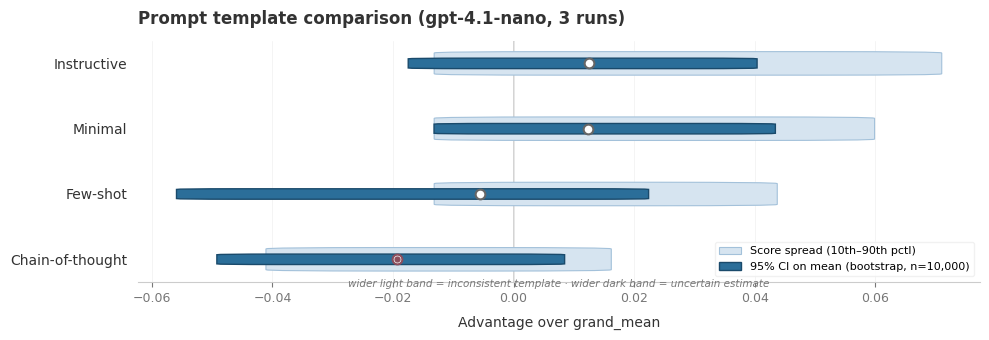

In [26]:
# Plot 1: mean advantage vs grand mean
result_2d = pstats.BenchmarkResult(
    scores=result.get_2d_scores(),
    template_labels=TEMPLATE_LABELS,
    input_labels=INPUT_LABELS,
)

fig = pstats.plot_mean_advantage(
    result_2d,
    reference="grand_mean",
    title=f"Prompt template comparison ({MODEL}, {N_RUNS} runs)",
    rng=np.random.default_rng(0),
)
plt.show()

/var/folders/65/p3y91scj2539sr5tshwg4ckr0000gn/T/ipykernel_15270/2593494352.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_runs[c].values for c in df_runs.columns], labels=df_runs.columns, showmeans=True)


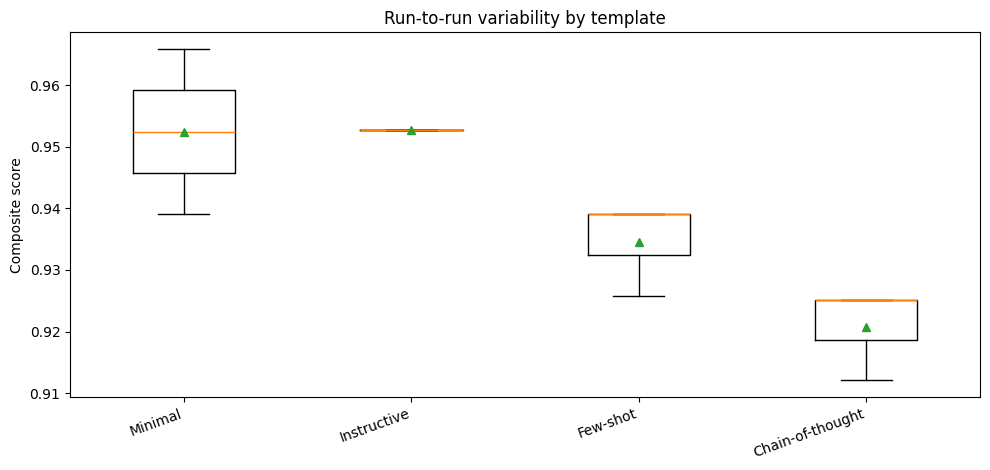

In [27]:
# Plot 2: run-to-run variability
template_run_scores = raw_scores.mean(axis=(1, 3))
df_runs = pd.DataFrame(template_run_scores.T, columns=TEMPLATE_LABELS)

plt.figure(figsize=(10, 4.8))
plt.boxplot([df_runs[c].values for c in df_runs.columns], labels=df_runs.columns, showmeans=True)
plt.xticks(rotation=20, ha="right")
plt.ylabel("Composite score")
plt.title("Run-to-run variability by template")
plt.tight_layout()
plt.show()

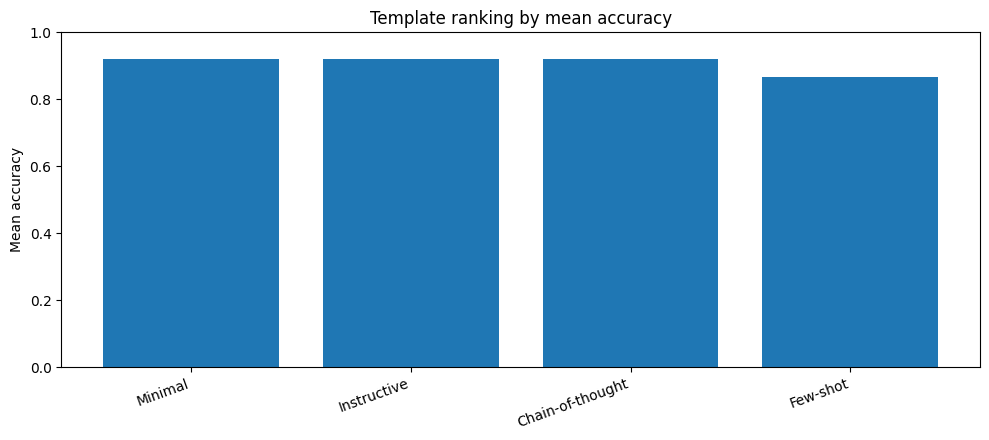

,template,accuracy
0,Minimal,0.920000
1,Instructive,0.920000
3,Chain-of-thought,0.920000
2,Few-shot,0.866667


In [28]:
# Plot 3: mean accuracy by template
accuracy_idx = EVALUATOR_NAMES.index("accuracy")
accuracy_by_template = raw_scores[:, :, :, accuracy_idx].mean(axis=(1, 2))

acc_df = pd.DataFrame({"template": TEMPLATE_LABELS, "accuracy": accuracy_by_template}).sort_values("accuracy", ascending=False)

plt.figure(figsize=(10, 4.5))
plt.bar(acc_df["template"], acc_df["accuracy"])
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.ylabel("Mean accuracy")
plt.title("Template ranking by mean accuracy")
plt.tight_layout()
plt.show()

acc_df